<a href="https://colab.research.google.com/github/jamaabl/projet/blob/master/jamaaibnolkabir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##exercice1

##importation des modules



In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


In [ ]:
#chargement des donnes MNIST
(X_train,Y_train) ,(X_test, Y_test) =keras.datasets.mnist.load_data()

print('trainset:',X_train.shape)
print('testset:',X_test.shape)

#normalisation des donnes
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


trainset: (60000, 28, 28)
testset: (10000, 28, 28)


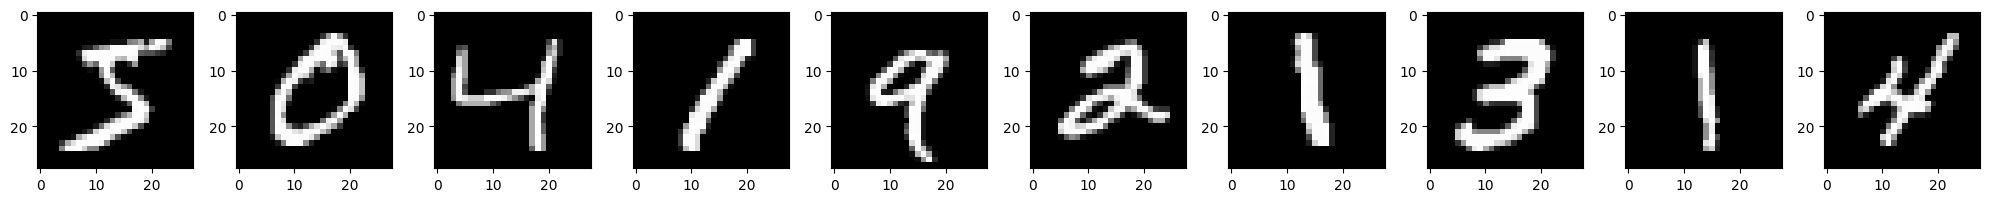

In [ ]:
# visualisation de quelques images
fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(20, 4))
for i in range(10): ax[i].imshow(X_train[i], cmap='gray')
plt.tight_layout()
plt.show()

##3. Configuration des Couches du Réseau de Neurones

In [ ]:
# Configuration des couches du réseau
model = keras.Sequential([
keras.layers.Flatten(input_shape=(28, 28)),# c.d'entre
keras.layers.Dense(128, activation='relu'),# c.cache
keras.layers.Dense(128, activation='relu'),#c.cache
keras.layers.Dense(10)#c.sortie
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

##4. Entrainement du Réseau de Neurones

In [ ]:
# Compilation du modele
model.compile(optimizer='adam',loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),

metrics=['accuracy'])
# Entrainement du modele
model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8778 - loss: 0.4112
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9685 - loss: 0.0988
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9782 - loss: 0.0663
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9843 - loss: 0.0476
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9874 - loss: 0.0399
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9895 - loss: 0.0339
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9921 - loss: 0.0231
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9932 - loss: 0.0209
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9945 - loss: 0.0180
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9939 - loss: 0.0174


##5. Évaluation du réseau de neurone sur les données de Test

In [ ]:
# Evaluation du modele
test_loss, test_acc = model.evaluate(X_test, Y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9701 - loss: 0.1415
Test accuracy: 0.975600004196167


##6. Création d'un modele prédictif

In [ ]:
# modele prédictif (softmax)
prediction_model = keras.Sequential([model, keras.layers.Softmax()])
predict_proba = prediction_model.predict(X_test)
predictions = np.argmax(predict_proba, axis=1)
print(predictions[:10])
print(Y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


##ex2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

##1. Dataset

dimensions de X: (100, 2)
dimensions de y: (100, 1)


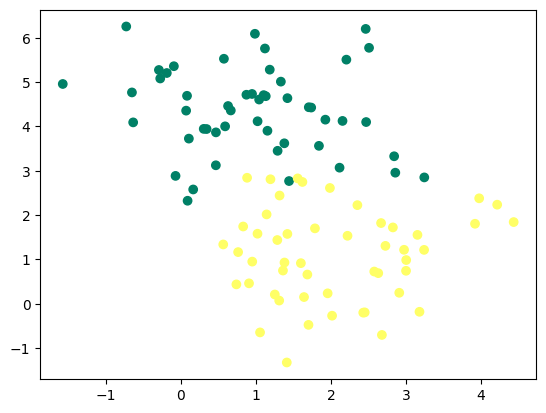

In [ ]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2,
random_state=0)
y = y.reshape((y.shape[0], 1))
print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)
plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

##2.fonction du model

In [ ]:
def initialisation(X):
  w=np.random.randn(X.shape[1],1)
  b=np.random.randn(1)
  return (w,b)
def model(X,w,b):
  z=X.dot(w)+b
  a=1/ (1+np.exp(-z))
  return a

def log_loss(a,y):
 return 1/ len(y)*np.sum(-y*np.log(a)-(1-y)*np.log(1-a))

def gradients(a, X,y):
  dw=1 /len(y) *np.dot(X.T,a-y)
  db=1 /len(y) *np.sum(a-y)
  return (dw,db)

def update(dw, db, w, b, learning_rate):
 w = w - learning_rate * dw
 b = b - learning_rate * db
 return (w, b)

def predict(X, w, b):
 a= model(X, w, b)
 # print(A)
 return a >= 0.5

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
# initialisation W, b
 w, b = initialisation(X)
 Loss = []
 for i in range(n_iter):
  a= model(X, w, b)
  Loss.append(log_loss(a, y))
  dW, db = gradients(a, X, y)
  W, b = update(dW, db, w, b, learning_rate)
 y_pred = predict(X, W, b)
 print(accuracy_score(y, y_pred))
 plt.plot(Loss)
 plt.show()
 return (W, b)

0.59


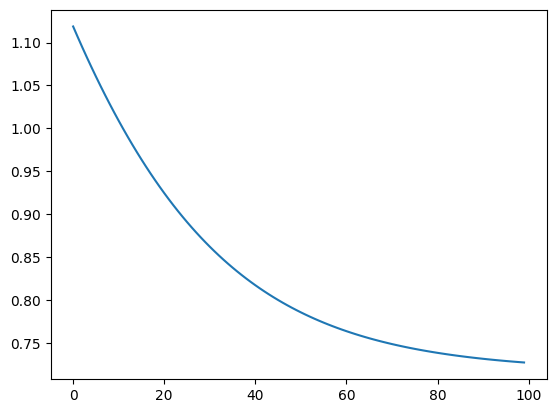

In [ ]:
W, b = artificial_neuron(X, y)

##3. Frontiere de décision

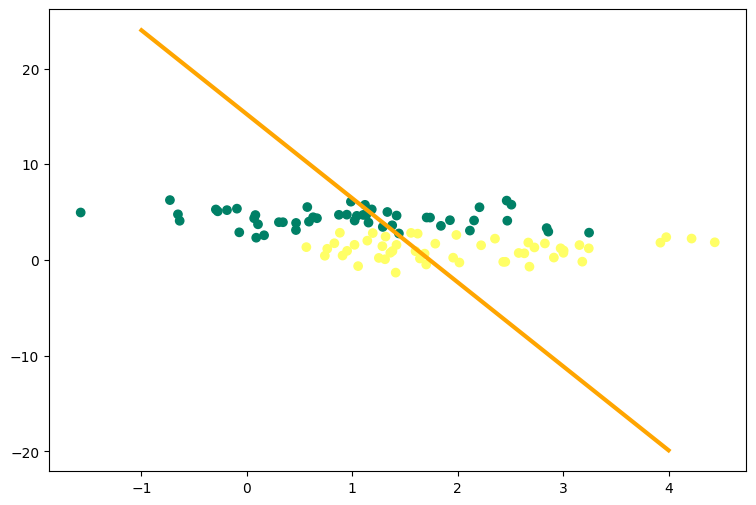

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
x1 = np.linspace(-1, 4, 100)
x2 = ( - W[0] * x1 - b) / W[1]
ax.plot(x1, x2, c='orange', lw=3)

#ex3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras


In [ ]:
df =pd.read_csv("AmesHousing.csv")

In [ ]:
#print(bd)#afficher
df.head()#affiche les 5 premières lignes.

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


2-analyser les valeurs manquantes (NaN) dans un DataFrame df et afficher un tableau des colonnes qui contiennent des données manquantes.

2-1 Création d’un DataFrame des valeurs manquantes

In [ ]:
VM = pd.DataFrame({
'Colonne': df.columns.values,#liste des noms des colonnes
'nbr de VM': df.isna().sum().values,#vérifie si chaque valeur est manquante
'% de VM': 100 * df.isna().sum().values / len(df),
})

#Garder seulement les colonnes avec valeurs manquantes
VM = VM[VM['nbr de VM'] > 0]

#Trier les colonnes par nombre de valeurs manquantes
print(VM.sort_values(by='nbr de VM', ascending=False).reset_index(drop=True))


           Colonne  nbr de VM    % de VM
0     Fireplace Qu       1422  48.532423
1     Lot Frontage        490  16.723549
2    Garage Finish        159   5.426621
3    Garage Yr Blt        159   5.426621
4      Garage Cond        159   5.426621
5      Garage Qual        159   5.426621
6      Garage Type        157   5.358362
7    Bsmt Exposure         83   2.832765
8   BsmtFin Type 2         81   2.764505
9        Bsmt Cond         80   2.730375
10       Bsmt Qual         80   2.730375
11  BsmtFin Type 1         80   2.730375
12    Mas Vnr Area         23   0.784983
13  Bsmt Half Bath          2   0.068259
14  Bsmt Full Bath          2   0.068259
15   Total Bsmt SF          1   0.034130
16    BsmtFin SF 2          1   0.034130
17     Bsmt Unf SF          1   0.034130
18    BsmtFin SF 1          1   0.034130
19      Electrical          1   0.034130
20     Garage Area          1   0.034130
21     Garage Cars          1   0.034130


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,IR1,Low,AllPub,...,0,0,0,0,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,...,0,0,0,0,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2006,WD,Normal,170000


Définir un seui

In [ ]:
#definir un seul
seuil=50

#Supprimer les colonnes dépassant le seuil
colonnes_supprimer = VM[VM['% de VM'] > seuil]['Colonne']

df = df.drop(columns=colonnes_supprimer)

In [ ]:
VM

,Colonne,nbr de VM,% de VM
4,Lot Frontage,490,16.723549
25,Mas Vnr Area,23,0.784983
29,Bsmt Qual,80,2.730375
30,Bsmt Cond,80,2.730375
31,Bsmt Exposure,83,2.832765
32,BsmtFin Type 1,80,2.730375
33,BsmtFin SF 1,1,0.034130
34,BsmtFin Type 2,81,2.764505
35,BsmtFin SF 2,1,0.034130
36,Bsmt Unf SF,1,0.034130


In [ ]:
#on affiche les variables catégorielles et les variables numériques
colonnes_avec_VM = df.columns[df.isna().sum() > 0]
for col in colonnes_avec_VM :
 print(col)
 print(df[col].unique()[:5])
 print('*'*30)


Lot Frontage
[141.  80.  81.  93.  74.]
******************************
Mas Vnr Area
[112.   0. 108.  20. 603.]
******************************
Bsmt Qual
['TA' 'Gd' 'Ex' nan 'Fa']
******************************
Bsmt Cond
['Gd' 'TA' nan 'Po' 'Fa']
******************************
Bsmt Exposure
['Gd' 'No' 'Mn' 'Av' nan]
******************************
BsmtFin Type 1
['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf']
******************************
BsmtFin SF 1
[ 639.  468.  923. 1065.  791.]
******************************
BsmtFin Type 2
['Unf' 'LwQ' 'BLQ' 'Rec' nan]
******************************
BsmtFin SF 2
[   0.  144. 1120.  163.  168.]
******************************
Bsmt Unf SF
[ 441.  270.  406. 1045.  137.]
******************************
Total Bsmt SF
[1080.  882. 1329. 2110.  928.]
******************************
Electrical
['SBrkr' 'FuseA' 'FuseF' 'FuseP' nan]
******************************
Bsmt Full Bath
[ 1.  0.  2.  3. nan]
******************************
Bsmt Half Bath
[ 0.  1. nan  2.]
**************

##On remplace ensuite les valeurs manquantes numériques d’une colonne par la moyenne de celles-ci.

In [ ]:
#on remplace les VM numériques par la moyenne de la colonne
num_VM = ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']
for n_col in num_VM:
 df[n_col] = df[n_col].fillna(df[n_col].mean()) #fillna() : remplace les NaN par cette moyenne

##On remplace également les valeurs manquantes catégorielles d’une colonne par le mode de celles-ci.

In [ ]:
#On remplace les VM nominales par le mode variable
nom_VM = [x for x in colonnes_avec_VM if x not in num_VM]
for nom_col in nom_VM:
 df[nom_col] =   df[nom_col].fillna(df[nom_col].mode().to_numpy()[0])#calcule la valeur la plus fréquente.to_numpy()[0] : récupère la première valeur du mode

##Pour appliquer un modèle de deep learning, l’ensemble de données ne doit contenir que des variables numériques. Alors, on va encoder les variables catégorielles. Dans un premier temps, on affiche le type de données de chaque colonne de la dataset.

In [ ]:
#encodage des variables catégorielles
#on affiche tout d'abord les types de données pour chaque colonne
types = pd.DataFrame({
'Colonne': df.select_dtypes(exclude='object').columns.values,
'Type': df.select_dtypes(exclude='object').dtypes.values})
print(types)

            Colonne     Type
0             Order    int64
1               PID    int64
2       MS SubClass    int64
3      Lot Frontage  float64
4          Lot Area    int64
5      Overall Qual    int64
6      Overall Cond    int64
7        Year Built    int64
8    Year Remod/Add    int64
9      Mas Vnr Area  float64
10     BsmtFin SF 1  float64
11     BsmtFin SF 2  float64
12      Bsmt Unf SF  float64
13    Total Bsmt SF  float64
14       1st Flr SF    int64
15       2nd Flr SF    int64
16  Low Qual Fin SF    int64
17      Gr Liv Area    int64
18   Bsmt Full Bath  float64
19   Bsmt Half Bath  float64
20        Full Bath    int64
21        Half Bath    int64
22    Bedroom AbvGr    int64
23    Kitchen AbvGr    int64
24    TotRms AbvGrd    int64
25       Fireplaces    int64
26    Garage Yr Blt  float64
27      Garage Cars  float64
28      Garage Area  float64
29     Wood Deck SF    int64
30    Open Porch SF    int64
31   Enclosed Porch    int64
32       3Ssn Porch    int64
33     Screen 

##Même si Pandas ne considère pas les données de la colonne MS SubClass étant nominaux, le descriptif de la dataset en dit autrement. Il arrive des fois que Pandas retourne incorrectement le type d’une colonne. Alors, on va sélectionner des variables qui représenteront notre dataset (pour ne pas avoir beaucoup de colonnes après l’encodage des valeurs catégorielles ce qui pourrait impliquer le sur-apprentissage du modèle) puis on transforme ces données catégorielles en utilisant la fonction get_dummies() de la bibliothèque pandas.

In [ ]:
#encodage des variables catégorielles,
#selon le descriptif de la dataset la colonne MS SubClass est nominale,
#Pandas a du mal à retourner son vrai type
df['MS SubClass'] = df['MS SubClass'].astype(str)
selection_de_variables = ['MS SubClass', 'MS Zoning', 'Lot Frontage',
'Lot Area',
 'Neighborhood', 'Overall Qual', 'Overall Cond',
 'Year Built', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
 'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
 'Kitchen AbvGr', 'TotRms AbvGrd', 'Garage Area',
 'Pool Area', 'SalePrice']
df = df[selection_de_variables]
#la dataset comprendera maintenant que 67 variables
df = pd.get_dummies(df)

##fractionne l’ensemble de données en des données d’entrainement et des données de test.

In [ ]:
#fractionner dataset en des données de test et de train
train = df.sample(frac = 0.8, random_state = 9)
test = df.drop(train.index)
#variable cible
train_cible = train.pop('SalePrice')
test_cible = test.pop('SalePrice')

##On standardise ensuite les variables afin de les avoir sur la même échelle.

In [57]:
#Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train = scaler.fit_transform(train)
test = scaler.transform(test)

##Construction du modèle d’apprentissage profond

modifier l’architecture pour améliorer la performance.

In [70]:
modele = keras.Sequential([
 keras.layers.Dense(128, activation = 'relu', input_shape =[train.shape[1]]),
 keras.layers.Dropout(0.3, seed = 2),
 keras.layers.Dense(128, activation = 'relu'),
 keras.layers.Dense(1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


On crée une instance du Sequential() de la bibliothèque Keras, celle-ci superpose un
ensemble de couches pour en créer un seul modèle. On lui passe en paramètre une liste
de couches qu’on souhaite utiliser pour notre modèle.
Comme vous allez le remarquer dans ce modèle, on a créé plusieurs couches denses et
une seule couche de type Dropout. La première couche est la couche d’entrée, son
nombre de neurones est égal au nombre de caractéristiques de l’ensemble de données.
Dans chaque couche on retrouve 64 neurones, ce nombre est le résultat optimal de
plusieurs tests. En effet, 64 neurones par couches pour l’exemple de cet ensemble de
données donnent un résultat assez précis.
.

Remarque : Il est recommandé d’essayer plusieurs chiffres jusqu’à l’obtention de résultats précis. Pour la couche Dropout, on a diminué de 30% le nombre des données d’entrée afin d’éviter le phénomène du overfitting. La graine prend une valeur de 2 pour avoir des résultats plus reproductibles. Finalement, la dernière couche dense avec un seul neurone est la couche de sortie. Par défaut, elle prend la fonction d’activation linéaire.

##Compilation du modèle
L’étape suivante est la compilation du modèle. Pour ce faire, il faut choisir :
 La fonction de perte : utilisée pour diminuer l’erreur. Plus l’erreur est faible plus le
modèle est précis ;
 L’optimiseur : aide à obtenir de meilleurs résultats pour la fonction de perte ;
 Métriques : utilisées pour évaluer le modèle.
Dans le code suivant nous avons utilisé la fonction de perte comme étant l’erreur
quadratique moyenne avec l’optimiseur RMSprop qu’on lui donne un taux
d’apprentissage de 0,001. Et pour la métrique nous avons utilisé l’erreur absolue
moyenne qui va avec la fonction de perte.

In [71]:
##optimiseur = tf.keras.optimizers.RMSprop(learning_rate = 0.001)
##modele.compile(loss = tf.keras.losses.MeanSquaredError(),optimizer =
##optimiseur,metrics = ['mae'])
optimiseur = tf.keras.optimizers.Adam(learning_rate=0.001)

modele.compile(
    loss='mse',
    optimizer=optimiseur,
    metrics=['mae']
)

##Entrainement du modèle
Dans ce qui suit, on entraine le modèle sur le jeu de données train. Celui-ci passe 70
fois sur l’ensemble de données pour en tirer le meilleur résultat possible. Ensuite, 20%
des données d’entrainement sont utilisées pour la validation.
La fonction fit() affiche la valeur de la fonction de perte et la métrique pour chaque
époque.  

In [72]:


training = modele.fit (train, train_cible, epochs = 100,
validation_split = 0.2)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 39416823808.0000 - mae: 182390.5156 - val_loss: 40651137024.0000 - val_mae: 183053.2344
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40922714112.0000 - mae: 184406.2812 - val_loss: 40533958656.0000 - val_mae: 182801.9688
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38589390848.0000 - mae: 180954.5938 - val_loss: 40129253376.0000 - val_mae: 181968.2031
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38876377088.0000 - mae: 181906.8125 - val_loss: 39189696512.0000 - val_mae: 180059.1875
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37324935168.0000 - mae: 177688.4531 - val_loss: 37516156928.0000 - val_mae: 176626.7188
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35808395264.0000 - mae: 173600.8125 - val_loss: 34943340544.0000 - val_mae: 171189.9688
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 31725920256.0000 - mae: 165236.9844 - val_loss: 31428861952

##Prévision
Avant de commencer d’utiliser le modèle pour nos prévisions, nous allons illustrer
comment la fonction de perte et la mae vont changer.  Remarquons que ces valeurs ont
diminué au fil du temps, alors le modèle est devenu plus précis.

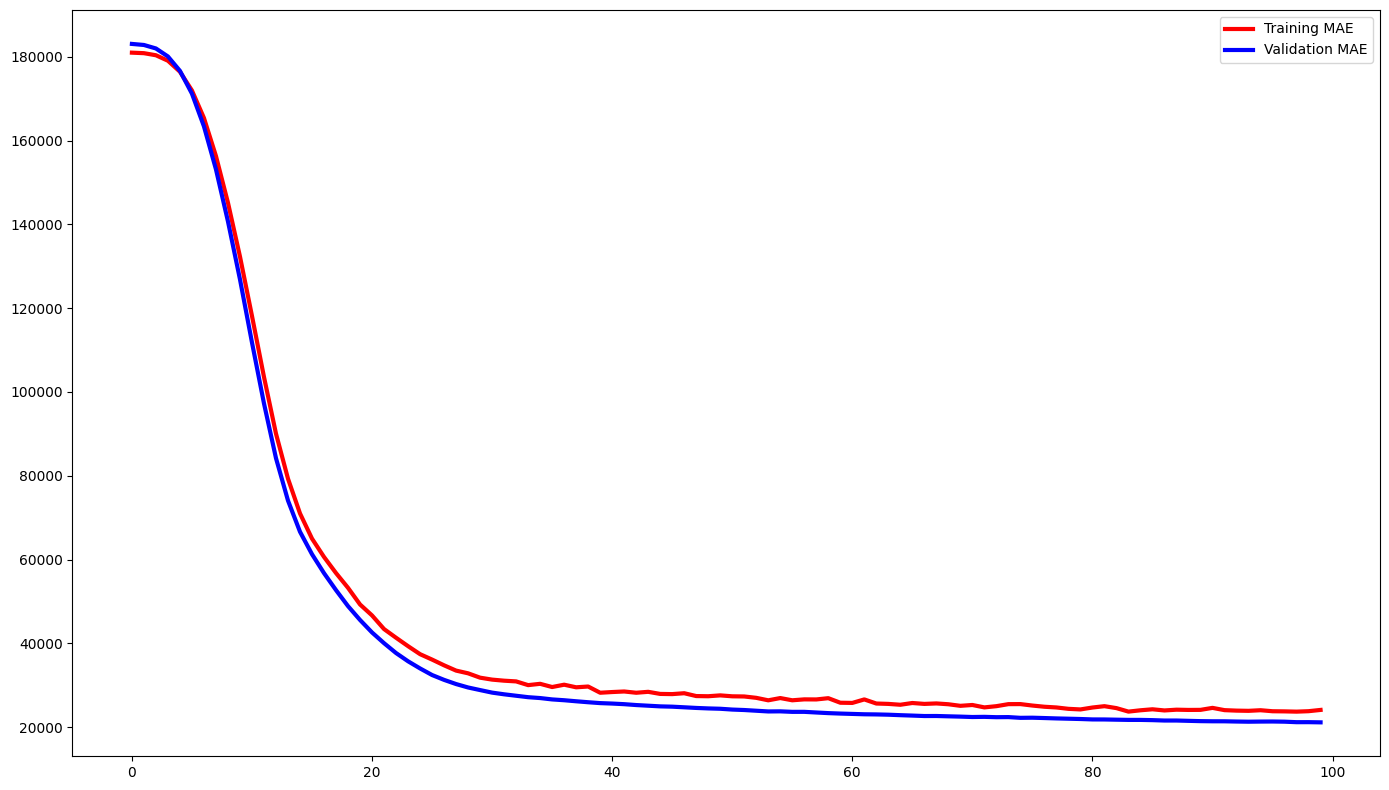

In [73]:
historique = pd.DataFrame(training.history)
historique['epoque'] = training.epoch
figure, axe = plt.subplots(figsize = (14,8))
num_epoque = historique.shape[0]
axe.plot(np.arange(0, num_epoque), historique["mae"],label = "Training MAE", lw = 3, color = 'red')
axe.plot(np.arange(0, num_epoque), historique["val_mae"],label =
"Validation MAE", lw = 3, color = 'blue')
axe.legend ()
plt.tight_layout()
plt.show()

On prend une unité des valeurs de test pour avoir sa prédiction en utilisant notre modèle.
Ensuite, on affiche la valeur de la prédiction et la valeur actuelle pour les comparer.

In [74]:
test1 = test[[10]]
test_prediction = modele.predict(test1).squeeze()
test_label = test_cible.iloc[10]

print("Prédiction du modèle = {:.2f}".format(test_prediction))
print("Valeur actuelle = {:.2f}".format(test_label))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prédiction du modèle = 317223.53
Valeur actuelle = 259000.00


##réalisation du travail(rapport)

##Amélioration du modèle d’apprentissage profond

Dans cette partie, nous avons apporté certaines modifications au modèle d’apprentissage profond afin d’améliorer ses performances pour la prédiction du prix des maisons à partir de la base de données Ames Housing Dataset.

#Modification de l’architecture du réseau neuronal

Dans la première version du modèle, le réseau neuronal comportait plusieurs couches denses avec un nombre de neurones plus faible. Afin d’augmenter la capacité d’apprentissage du modèle et de mieux capturer les relations entre les variables explicatives et la variable cible (SalePrice), nous avons modifié l’architecture du réseau.

La nouvelle architecture du modèle est composée de :

une couche dense contenant 128 neurones avec la fonction d’activation ReLU ;

une couche Dropout avec un taux de 0.3 afin de réduire le phénomène de sur-apprentissage (overfitting) ;

une seconde couche dense contenant 128 neurones avec la fonction d’activation ReLU ;

une couche de sortie contenant un seul neurone, utilisée pour prédire la valeur du prix de la maison.

L’augmentation du nombre de neurones permet au réseau neuronal de modéliser des relations plus complexes entre les variables du dataset.

#Utilisation de l’optimiseur Adam

Dans cette nouvelle configuration du modèle, nous avons utilisé l’optimiseur Adam optimizer pour entraîner le réseau neuronal.

L’optimiseur Adam est largement utilisé dans les modèles de Deep Learning car il combine les avantages des méthodes d’optimisation basées sur le momentum et l’adaptation du taux d’apprentissage. Il permet généralement une convergence plus rapide et plus stable lors de l’apprentissage du modèle.

#Résultat de la prédiction

Après l’entraînement du modèle, nous avons testé celui-ci sur une observation de l’ensemble de données de test afin d’évaluer sa capacité de prédiction.

Les résultats obtenus sont les suivants :

Prédiction du modèle : 317223.53

Valeur réelle : 259000.00

On constate que le modèle fournit une estimation du prix de la maison relativement proche de la valeur réelle, bien qu’une différence subsiste entre la valeur prédite et la valeur observée.

#Analyse des résultats

Après l’entraînement et l’évaluation des deux modèles, nous avons comparé les prédictions obtenues afin d’analyser l’impact des modifications apportées à l’architecture du réseau neuronal ainsi que l’utilisation de l’optimiseur Adam optimizer avec la base de données Ames Housing Dataset.

Les résultats montrent que l’erreur de prédiction a légèrement diminué après l’amélioration du modèle.

Erreur du modèle initial :

320525.59 − 259000 = 61525.59

Dans ce premier cas, le modèle prédit un prix supérieur à la valeur réelle d’environ 61 525.59 dollars.

Erreur du modèle amélioré :

317223.53 − 259000 = 58223.53

Après modification de l’architecture du réseau neuronal (augmentation du nombre de neurones à 128 et ajout d’une couche Dropout) et utilisation de l’optimiseur Adam, l’erreur de prédiction devient 58 223.53 dollars.

On observe donc une réduction de l’erreur d’environ :

61525.59 − 58223.53 = 3302.06 dollars

Cette diminution indique que les modifications apportées au modèle permettent d’améliorer légèrement la précision des prédictions. Cependant, cette amélioration reste relativement limitée pour cet exemple particulier. Une évaluation plus complète doit être réalisée sur l’ensemble des données de test en utilisant des métriques globales telles que l’erreur absolue moyenne (MAE).